## Data Analysis Assignment Questions

### Customer Analysis

1. Total kitne unique customers hain?
2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
3. Gender ke hisaab se total customers kitne hain?
4. Har age category ki average rating calculate karein.
5. Har gender ki average purchase value calculate karein.
6. Kis country mein sabse zyada customers hain?
7. Har country ki average review rating calculate karein.
8. Har country ka average engagement score nikaalein.
9. Kis age group ki engagement sabse zyada hai?
10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dfc  = pd.read_excel('customers.xlsx')

# Total kitne unique customers hain?

In [4]:
dfc['CustomerID'].nunique()

100

# Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

In [5]:
dfc['Age_Category'] = pd.cut(dfc.Age,bins=[18,30,40,50,60,70,],
                             labels=['Young','Adult','Senior','Old','Older'])

In [6]:
dfc

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4,Adult
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6,Young
3,4,David Garcia,david.garcia@example.com,Male,25,8,Young
4,5,Emma Miller,emma.miller@example.com,Female,41,4,Senior
...,...,...,...,...,...,...,...
95,96,Emily Gonzalez,emily.gonzalez@example.com,Female,38,10,Adult
96,97,Emily Rodriguez,emily.rodriguez@example.com,Female,51,3,Old
97,98,Chris Lopez,chris.lopez@example.com,Female,55,10,Old
98,99,Laura Hernandez,laura.hernandez@example.com,Male,41,5,Senior


# Gender ke hisaab se total customers kitne hain?

In [7]:
dfc.value_counts('Gender')

Gender
Female    54
Male      46
dtype: int64

# Har age category ki average rating calculate karein.

In [8]:
dfc.groupby('Age_Category')['Age'].mean()

Age_Category
Young     24.681818
Adult     35.125000
Senior    44.500000
Old       55.437500
Older     65.071429
Name: Age, dtype: float64

# # Har gender ki average purchase value calculate karein.

In [9]:
dfcj = pd.read_excel("customer_journey.xlsx")
dfcju = pd.read_csv("customer_journey_updated.csv")
dfcr = pd.read_excel("customer_reviews.xlsx")
dfce = pd.read_excel("engagement_data.xlsx")
dfcg = pd.read_excel("geography.xlsx")
dfcp = pd.read_excel("products.xlsx")
dfcp

,ProductID,ProductName,Category,Price
0,1,Running Shoes,Sports,223.75
1,2,Fitness Tracker,Sports,196.68
2,3,Yoga Mat,Sports,485.32
3,4,Dumbbells,Sports,26.21
4,5,Soccer Ball,Sports,41.26
5,6,Tennis Racket,Sports,36.07
6,7,Basketball,Sports,225.12
7,8,Football Helmet,Sports,44.75
8,9,Baseball Glove,Sports,327.36
9,10,Golf Clubs,Sports,81.59


In [10]:
datasets = {
    "Customers": dfc,
    "Products": dfcp,
    "Geography": dfcg,
    "Engagement": dfce,
    "Reviews": dfcr,
    "Journey": dfcj,
    "Journey Updated": dfcju
}
for name,df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Customers
['CustomerID', 'CustomerName', 'Email', 'Gender', 'Age', 'GeographyID', 'Age_Category']

Products
['ProductID', 'ProductName', 'Category', 'Price']

Geography
['ID', 'Region', 'City']

Engagement
['EngagementID', 'ContentID', 'ContentType', 'Likes', 'EngagementDate', 'CompaignID', 'ProductID', 'ViewsClickCombined']

Reviews
['ReviewID', 'CustomerID', 'ProductID', 'ReviewDate', 'Rating', 'ReviewText']

Journey
['JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']

Journey Updated
['Unnamed: 0', 'JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']


In [11]:
merged_dfc_dfcj = pd.merge(dfc,dfcj, on="CustomerID")
merged_dfc_dfcj 

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,JourneyID,ProductId,VisitDate,Stage,Action,Duration
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,ProductPage,View,64.0
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,55,7,2024-03-17,Checkout,Drop-off,NaN
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,380,11,2023-05-29,Checkout,Drop-off,NaN
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,561,20,2025-07-04,Homepage,Click,225.0
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,577,1,2025-12-17,Homepage,Click,115.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4006,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,3524,2,2024-05-06,homepage,Click,82.0
4007,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,3642,4,2025-05-25,ProductPage,Click,160.0
4008,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,3853,13,2025-07-18,Homepage,View,244.0
4009,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,3855,8,2023-08-13,Homepage,Click,69.0


In [12]:
dfcp = dfcp.rename(columns={'ProductID':'ProductId'})

In [13]:
merged_dfc_dfcj_dfcp = pd.merge(merged_dfc_dfcj,dfcp , on='ProductId')
merged_dfc_dfcj_dfcp

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,JourneyID,ProductId,VisitDate,Stage,Action,Duration,ProductName,Category,Price
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,ProductPage,View,64.0,Boxing Gloves,Sports,262.32
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,561,20,2025-07-04,Homepage,Click,225.0,Boxing Gloves,Sports,262.32
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,816,20,2023-12-17,Homepage,Click,71.0,Boxing Gloves,Sports,262.32
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,2072,20,2023-05-29,Checkout,Drop-off,NaN,Boxing Gloves,Sports,262.32
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,2547,20,2024-01-10,ProductPage,Click,70.0,Boxing Gloves,Sports,262.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4006,98,Chris Lopez,chris.lopez@example.com,Female,55,10,Old,1157,16,2024-08-21,ProductPage,Click,110.0,Kayak,Sports,259.40
4007,98,Chris Lopez,chris.lopez@example.com,Female,55,10,Old,1758,16,2025-07-04,ProductPage,View,146.0,Kayak,Sports,259.40
4008,98,Chris Lopez,chris.lopez@example.com,Female,55,10,Old,2127,16,2024-12-18,Checkout,Purchase,292.0,Kayak,Sports,259.40
4009,99,Laura Hernandez,laura.hernandez@example.com,Male,41,5,Senior,265,16,2023-03-09,Homepage,Click,235.0,Kayak,Sports,259.40


In [14]:
merged_dfc_dfcj_dfcp.groupby('Gender')['Price'].mean().round(2)

Gender
Female    203.75
Male      206.73
Name: Price, dtype: float64

#  Kis country mein sabse zyada customers hain?

In [15]:
merged_dfc_dfcg = pd.merge(
    dfc,
    dfcg,
    left_on='GeographyID',
    right_on='ID'
)

In [16]:
merged_dfc_dfcg

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,ID,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,2,Germany,Berlin
1,10,Chris Davis,chris.davis@example.com,Female,46,2,Senior,2,Germany,Berlin
2,17,Daniel Thomas,daniel.thomas@example.com,Female,46,2,Senior,2,Germany,Berlin
3,22,Alex Wilson,alex.wilson@example.com,Male,53,2,Old,2,Germany,Berlin
4,35,Robert Rodriguez,robert.rodriguez@example.com,Female,46,2,Senior,2,Germany,Berlin
...,...,...,...,...,...,...,...,...,...,...
95,34,Daniel Miller,daniel.miller@example.com,Male,57,3,Old,3,France,Paris
96,36,Emma Johnson,emma.johnson@example.com,Female,63,3,Older,3,France,Paris
97,50,Olivia Miller,olivia.miller@example.com,Male,36,3,Adult,3,France,Paris
98,88,James Brown,james.brown@example.com,Male,42,3,Senior,3,France,Paris


In [17]:
merged_dfc_dfcg.groupby('Region').size()

Region
Austria        10
Belgium         9
France          5
Germany        11
Italy          12
Netherlands     9
Spain          18
Sweden          8
Switzerland     8
UK             10
dtype: int64

# Har country ki average review rating calculate karein.

In [18]:
merged_dfc_dfcr = pd.merge(dfc,dfcr , on='CustomerID')
merged_dfc_dfcr

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,ReviewID,ProductID,ReviewDate,Rating,ReviewText
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,357,3,2024-04-01,4,Five stars for the quick delivery.
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,525,1,2023-11-23,4,"I love this product, will buy again!"
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,605,3,2023-06-17,3,"The product is okay, but the instruction..."
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,709,16,2023-02-25,5,Customer support was very helpful.
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,1155,12,2025-01-09,5,Exceeded my expectations!
...,...,...,...,...,...,...,...,...,...,...,...,...
1358,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,912,2,2025-10-27,2,Disappointed with the performance.
1359,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1020,5,2025-09-02,3,"Average experience, nothing special."
1360,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1040,19,2024-03-02,5,The build quality is impressive.
1361,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1125,12,2025-07-20,2,"Good quality, but could be cheaper."


In [19]:
merged_dfc_dfcg_dfcr = pd.merge(
    merged_dfc_dfcr,
    dfcg,
    left_on='GeographyID',
    right_on='ID'
)

In [20]:
merged_dfc_dfcg_dfcr.groupby('Region')['Rating'].mean().round(2)

Region
Austria        3.65
Belgium        3.58
France         3.75
Germany        3.74
Italy          3.68
Netherlands    3.69
Spain          3.77
Sweden         3.69
Switzerland    3.49
UK             3.72
Name: Rating, dtype: float64

# Har country ka average engagement score nikaalein.

In [21]:
datasets = {
    "Customers": dfc,
    "Products": dfcp,
    "Geography": dfcg,
    "Engagement": dfce,
    "Reviews": dfcr,
    "Journey": dfcj,
    "Journey Updated": dfcju
}
for name,df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Customers
['CustomerID', 'CustomerName', 'Email', 'Gender', 'Age', 'GeographyID', 'Age_Category']

Products
['ProductId', 'ProductName', 'Category', 'Price']

Geography
['ID', 'Region', 'City']

Engagement
['EngagementID', 'ContentID', 'ContentType', 'Likes', 'EngagementDate', 'CompaignID', 'ProductID', 'ViewsClickCombined']

Reviews
['ReviewID', 'CustomerID', 'ProductID', 'ReviewDate', 'Rating', 'ReviewText']

Journey
['JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']

Journey Updated
['Unnamed: 0', 'JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']


In [22]:
merged_dfc_dfcj = pd.merge(dfc,dfcj, on='CustomerID')
merged_dfc_dfcj = merged_dfc_dfcj.rename(columns={'ProductId':'ProductID'})
                                

In [23]:
merged_dfc_dfcj_dfce = pd.merge(merged_dfc_dfcj ,dfce, on='ProductID')
merged_dfc_dfcj_dfce.columns

Index(['CustomerID', 'CustomerName', 'Email', 'Gender', 'Age', 'GeographyID',
       'Age_Category', 'JourneyID', 'ProductID', 'VisitDate', 'Stage',
       'Action', 'Duration', 'EngagementID', 'ContentID', 'ContentType',
       'Likes', 'EngagementDate', 'CompaignID', 'ViewsClickCombined'],
      dtype='object')

In [24]:
merged_dfc_dfcj_dfce_dfcg = pd.merge(merged_dfc_dfcj_dfce, dfcg,left_on='GeographyID',right_on='ID')
merged_dfc_dfcj_dfce_dfcg 

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,JourneyID,ProductID,VisitDate,...,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ViewsClickCombined,ID,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,2,48,Blog,114,2023-03-28,18,5280-532,2,Germany,Berlin
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,4,43,Video,17,2025-01-21,19,2766-257,2,Germany,Berlin
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,26,31,Video,2,2025-06-04,20,1742-71,2,Germany,Berlin
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,29,15,video,0,2025-08-02,17,58-2,2,Germany,Berlin
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,57,8,Video,3,2025-01-12,7,944-91,2,Germany,Berlin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927477,88,James Brown,james.brown@example.com,Male,42,3,Senior,3029,16,2025-10-21,...,4531,10,blog,316,2023-06-23,15,4851-1250,3,France,Paris
927478,88,James Brown,james.brown@example.com,Male,42,3,Senior,3029,16,2025-10-21,...,4548,49,Newsletter,176,2023-12-10,14,5619-1255,3,France,Paris
927479,88,James Brown,james.brown@example.com,Male,42,3,Senior,3029,16,2025-10-21,...,4570,12,Newsletter,108,2024-05-12,10,4970-1172,3,France,Paris
927480,88,James Brown,james.brown@example.com,Male,42,3,Senior,3029,16,2025-10-21,...,4610,14,newsletter,17,2024-09-20,20,1178-162,3,France,Paris


In [25]:
merged_dfc_dfcj_dfce_dfcg.head(10)

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,JourneyID,ProductID,VisitDate,...,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ViewsClickCombined,ID,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,2,48,Blog,114,2023-03-28,18,5280-532,2,Germany,Berlin
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,4,43,Video,17,2025-01-21,19,2766-257,2,Germany,Berlin
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,26,31,Video,2,2025-06-04,20,1742-71,2,Germany,Berlin
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,29,15,video,0,2025-08-02,17,58-2,2,Germany,Berlin
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,57,8,Video,3,2025-01-12,7,944-91,2,Germany,Berlin
5,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,82,49,Socialmedia,142,2023-04-26,8,1354-425,2,Germany,Berlin
6,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,85,34,Video,0,2025-05-08,18,36-3,2,Germany,Berlin
7,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,125,44,SOCIALMEDIA,29,2023-08-22,12,621-199,2,Germany,Berlin
8,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,206,14,blog,7,2025-04-06,9,1992-109,2,Germany,Berlin
9,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,28,20,2025-09-26,...,219,45,Socialmedia,376,2023-03-15,5,2900-1294,2,Germany,Berlin


In [32]:
merged_dfc_dfcj_dfce_dfcg.dropna(subset=['Views','Click'], inplace=True)

In [33]:
merged_dfc_dfcj_dfce_dfcg['Views'] = merged_dfc_dfcj_dfce_dfcg['Views'].astype(int)
merged_dfc_dfcj_dfce_dfcg['Click'] = merged_dfc_dfcj_dfce_dfcg['Click'].astype(int)


In [31]:
merged_dfc_dfcj_dfce_dfcg[['Views','Click']]=merged_dfc_dfcj_dfce_dfcg['ViewsClickCombined'].str.split('-',expand=True)


In [ ]:
merged_dfc_dfcj_dfce_dfcg.groupby('Region')['Views'].mean().round(2)

# Kis age group ki engagement sabse zyada hai?

In [34]:
merged_dfc_dfcj_dfce_dfcg.groupby('Age_Category')['Views'].mean()

Age_Category
Young     2536.966005
Adult     2545.813378
Senior    2549.702437
Old       2548.795036
Older     2539.671072
Name: Views, dtype: float64

# Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

In [35]:
merged_dfc_dfcr = pd.merge(dfc,dfcr , on='CustomerID')
merged_dfc_dfcr

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,ReviewID,ProductID,ReviewDate,Rating,ReviewText
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,357,3,2024-04-01,4,Five stars for the quick delivery.
1,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,525,1,2023-11-23,4,"I love this product, will buy again!"
2,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,605,3,2023-06-17,3,"The product is okay, but the instruction..."
3,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,709,16,2023-02-25,5,Customer support was very helpful.
4,1,Emma Anderson,emma.anderson@example.com,Male,50,2,Senior,1155,12,2025-01-09,5,Exceeded my expectations!
...,...,...,...,...,...,...,...,...,...,...,...,...
1358,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,912,2,2025-10-27,2,Disappointed with the performance.
1359,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1020,5,2025-09-02,3,"Average experience, nothing special."
1360,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1040,19,2024-03-02,5,The build quality is impressive.
1361,100,Jane Brown,jane.brown@example.com,Female,45,10,Senior,1125,12,2025-07-20,2,"Good quality, but could be cheaper."


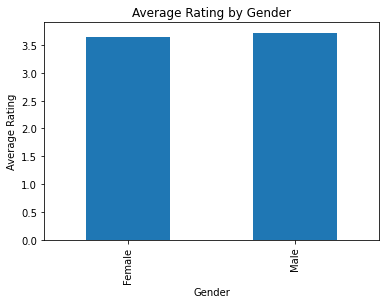

In [36]:
merged_dfc_dfcr.groupby('Gender')['Rating'].mean().plot(kind='bar')

plt.title('Average Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating')

plt.show()

# Sabse zyada purchase hone wale Top 10 products dikhayein.

In [37]:
dfcp = dfcp.rename(columns={'ProductID':'ProductId'})
dfcp

,ProductId,ProductName,Category,Price
0,1,Running Shoes,Sports,223.75
1,2,Fitness Tracker,Sports,196.68
2,3,Yoga Mat,Sports,485.32
3,4,Dumbbells,Sports,26.21
4,5,Soccer Ball,Sports,41.26
5,6,Tennis Racket,Sports,36.07
6,7,Basketball,Sports,225.12
7,8,Football Helmet,Sports,44.75
8,9,Baseball Glove,Sports,327.36
9,10,Golf Clubs,Sports,81.59


In [38]:
merged_dfcp_dfcj = pd.merge(dfcp,dfcj , on='ProductId')
merged_dfcp_dfcj 

,ProductId,ProductName,Category,Price,JourneyID,CustomerID,VisitDate,Stage,Action,Duration
0,1,Running Shoes,Sports,223.75,15,9,2025-11-04,ProductPage,View,292.0
1,1,Running Shoes,Sports,223.75,19,9,2024-08-15,Homepage,View,187.0
2,1,Running Shoes,Sports,223.75,22,12,2025-11-19,Homepage,Click,20.0
3,1,Running Shoes,Sports,223.75,23,58,2023-07-05,Homepage,View,48.0
4,1,Running Shoes,Sports,223.75,62,42,2024-10-22,Homepage,View,186.0
...,...,...,...,...,...,...,...,...,...,...
4006,20,Boxing Gloves,Sports,262.32,3127,94,2024-01-27,Homepage,Click,39.0
4007,20,Boxing Gloves,Sports,262.32,746,32,2024-08-25,Homepage,View,127.0
4008,20,Boxing Gloves,Sports,262.32,1533,71,2025-05-05,Homepage,View,154.0
4009,20,Boxing Gloves,Sports,262.32,2015,42,2025-08-01,Checkout,Drop-off,NaN


In [39]:
merged_dfcp_dfcj.groupby('ProductName')['JourneyID'].count().sort_values(ascending=False).head(10)

ProductName
Boxing Gloves      224
Fitness Tracker    223
Kayak              218
Dumbbells          216
Running Shoes      212
Baseball Glove     210
Ice Skates         208
Hockey Stick       205
Basketball         203
Soccer Ball        201
Name: JourneyID, dtype: int64

# Sabse zyada reviews kis products ko mile hain?

In [40]:
dfcp = dfcp.rename(columns={'ProductId':'ProductID'})

In [41]:
merged_dfcr_dfcp = pd.merge(dfcr,dfcp , on='ProductID')

In [42]:
merged_dfcr_dfcp.groupby('ProductName')['ReviewID'].count().sort_values(ascending=False)

ProductName
Ice Skates         79
Fitness Tracker    76
Soccer Ball        75
Kayak              75
Dumbbells          75
Swim Goggles       73
Baseball Glove     73
Surfboard          72
Tennis Racket      72
Climbing Rope      69
Ski Boots          67
Yoga Mat           65
Football Helmet    64
Golf Clubs         64
Basketball         64
Hockey Stick       63
Running Shoes      63
Boxing Gloves      59
Volleyball         59
Cycling Helmet     56
Name: ReviewID, dtype: int64

# Sabse zyada engagement wale Top 10 products identify karein.

In [43]:
dfcp = dfcp.rename(columns={'ProductId':'ProductID'})

In [44]:
merged_dfce_dfcp = pd.merge(dfce,dfcp, on='ProductID')

In [45]:
merged_dfce_dfcp[['Views','Click']]=merged_dfc_dfcj_dfce_dfcg['ViewsClickCombined'].str.split('-',expand=True)

In [46]:
merged_dfce_dfcp['Views'] = merged_dfc_dfcj_dfce_dfcg['Views'].astype(int)
merged_dfce_dfcp['Click'] = merged_dfc_dfcj_dfce_dfcg['Click'].astype(int)

In [47]:
merged_dfce_dfcp.groupby('ProductName')['Views'].sum().sort_values(ascending=False).head(10)

ProductName
Basketball       632295
Running Shoes    613482
Soccer Ball      588899
Tennis Racket    588096
Kayak            583113
Climbing Rope    581680
Dumbbells        580824
Yoga Mat         571937
Boxing Gloves    571937
Swim Goggles     571937
Name: Views, dtype: int64

# Har product category ki average rating calculate karein.

In [48]:
merged_dfcr_dfcp = pd.merge(dfcr,dfcp , on='ProductID')

In [49]:
merged_dfcr_dfcp.groupby('Category')['Rating'].mean()

Category
Sports    3.68672
Name: Rating, dtype: float64

In [50]:
dfcp['Category'].value_counts()

Sports    20
Name: Category, dtype: int64

# Har category ki average engagement calculate karein.

In [51]:
merged_dfcp_dfce = pd.merge(dfcp,dfce , on='ProductID')

In [52]:
merged_dfcp_dfce[['Views','Click']]=merged_dfc_dfcj_dfce_dfcg['ViewsClickCombined'].str.split('-',expand=True)

In [53]:
merged_dfcp_dfce['Views'] = merged_dfc_dfcj_dfce_dfcg['Views'].astype(int)
merged_dfcp_dfce['Click'] = merged_dfc_dfcj_dfce_dfcg['Click'].astype(int)

In [54]:
merged_dfcp_dfce.groupby('Category')['Views'].mean().round(2)

Category
Sports    2443.58
Name: Views, dtype: float64

# Har category ki average views aur clicks compare karein.

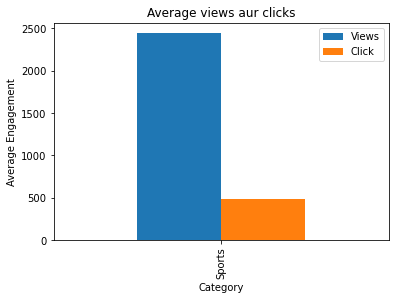

In [55]:
merged_dfcp_dfce.groupby('Category')[['Views','Click']].mean().round(2).plot(kind='bar')

plt.title('Average views aur clicks')
plt.xlabel('Category')
plt.ylabel('Average Engagement')

plt.show()

# Lowest rated Top 10 products kaun se hain?

In [56]:
merged_dfcr_dfcp.groupby('ProductName')['Rating'].mean().sort_values(ascending = True).head(10).round(2)

ProductName
Golf Clubs       3.48
Yoga Mat         3.52
Tennis Racket    3.56
Running Shoes    3.57
Volleyball       3.58
Boxing Gloves    3.61
Dumbbells        3.63
Surfboard        3.65
Soccer Ball      3.67
Hockey Stick     3.67
Name: Rating, dtype: float64

# Highest rated Top 10 products kaun se hain?

In [57]:
merged_dfcr_dfcp.groupby('ProductName')['Rating'].mean().sort_values(ascending = False).head(10).round(2)

ProductName
Climbing Rope      3.91
Swim Goggles       3.84
Cycling Helmet     3.80
Kayak              3.79
Basketball         3.78
Fitness Tracker    3.78
Ski Boots          3.73
Baseball Glove     3.73
Football Helmet    3.70
Ice Skates         3.70
Name: Rating, dtype: float64

In [58]:
merged_dfcp_dfce

,ProductID,ProductName,Category,Price,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ViewsClickCombined,Views,Click
0,1,Running Shoes,Sports,223.75,37,32,Video,400,2023-01-24,7,9759-3095,5280,532
1,1,Running Shoes,Sports,223.75,43,34,Newsletter,92,2023-08-12,8,3640-370,2766,257
2,1,Running Shoes,Sports,223.75,46,5,Blog,11,2024-09-29,1,2549-228,1742,71
3,1,Running Shoes,Sports,223.75,59,37,video,0,2025-07-17,10,219-7,58,2
4,1,Running Shoes,Sports,223.75,72,19,BLOG,657,2023-01-06,17,6991-2499,944,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4618,20,Boxing Gloves,Sports,262.32,4550,48,BLOG,35,2024-05-31,3,3002-332,489,209
4619,20,Boxing Gloves,Sports,262.32,4552,45,Socialmedia,25,2023-10-29,3,576-129,102,4
4620,20,Boxing Gloves,Sports,262.32,4562,18,socialmedia,554,2023-04-07,16,7357-1399,4524,877
4621,20,Boxing Gloves,Sports,262.32,4579,1,Blog,516,2023-08-14,5,6801-2286,4743,1140


# Product popularity ko bar chart ke zariye visualize karein

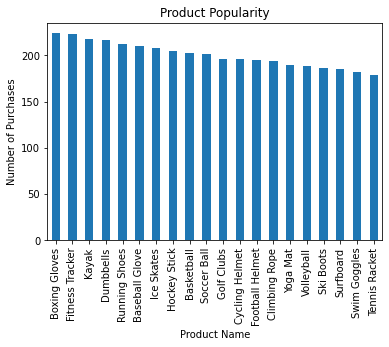

In [59]:
merged_dfcp_dfcj.groupby('ProductName')['JourneyID'].count().sort_values(ascending=False).plot(kind='bar')

plt.title('Product Popularity')
plt.xlabel('Product Name')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=90)

plt.show()

# Total Views, Total Clicks aur Total Likes calculate karein.

In [60]:
dfce[['Views','Click']]=merged_dfc_dfcj_dfce_dfcg['ViewsClickCombined'].str.split('-',expand=True)

In [61]:
dfce['Views'] = merged_dfc_dfcj_dfce_dfcg['Views'].astype(int)
dfce['Click'] = merged_dfc_dfcj_dfce_dfcg['Click'].astype(int)

In [62]:
dfce.dropna(subset=['Views','Click'], inplace=True)

In [63]:
dfce[['Views','Click','Likes']].sum()

Views    11296666
Click     2261913
Likes      528726
dtype: int64

# Overall Engagement Rate calculate karein.

In [64]:
Engagement_Rate = ((2261913+528726)/11296666)*100
print(Engagement_Rate)

24.703208893668275


# Har product ka Engagement Rate compare karein.

In [65]:
engagement = merged_dfcp_dfce.groupby('ProductName')[['Views','Click','Likes']].sum()
engagement

,Views,Click,Likes
ProductName,,,
Baseball Glove,517764,101330,27452
Basketball,622219,124725,29583
Boxing Gloves,571937,114522,26512
Climbing Rope,589197,119060,27238
Cycling Helmet,526167,105043,23685
Dumbbells,571995,114524,25002
Fitness Tracker,551679,110167,17205
Football Helmet,529535,107648,23367
Golf Clubs,561002,112662,28716


In [66]:
engagement = merged_dfcp_dfce.groupby('ProductName')[['Views','Click','Likes']].sum()

In [67]:
engagement['EngagementRate'] = (
    (engagement['Click'] + engagement['Likes'])
    / engagement['Views']
) * 100

In [68]:
engagement

,Views,Click,Likes,EngagementRate
ProductName,,,,
Baseball Glove,517764,101330,27452,24.872722
Basketball,622219,124725,29583,24.799628
Boxing Gloves,571937,114522,26512,24.659010
Climbing Rope,589197,119060,27238,24.830065
Cycling Helmet,526167,105043,23685,24.465236
Dumbbells,571995,114524,25002,24.392871
Fitness Tracker,551679,110167,17205,23.088064
Football Helmet,529535,107648,23367,24.741519
Golf Clubs,561002,112662,28716,25.200980


<Figure size 864x432 with 0 Axes>

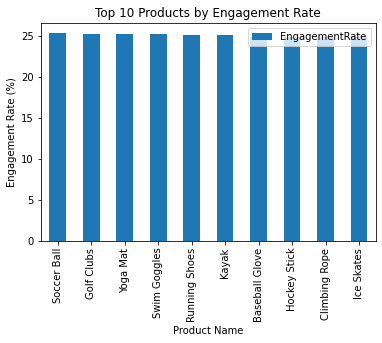

In [69]:
plt.figure(figsize=(12,6))

engagement.sort_values('EngagementRate', ascending=False).head(10).plot(
    kind='bar',
    y='EngagementRate'
)

plt.title('Top 10 Products by Engagement Rate')
plt.xlabel('Product Name')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=90)

plt.show()

# Sabse zyada viewed aur sabse zyada clicked products identify karein.

In [70]:
engagement.sort_values(by='Views', ascending=False)

,Views,Click,Likes,EngagementRate
ProductName,,,,
Basketball,622219,124725,29583,24.799628
Running Shoes,601983,119737,31106,25.057684
Climbing Rope,589197,119060,27238,24.830065
Tennis Racket,587236,118002,22967,24.005511
Soccer Ball,582481,117162,30009,25.266232
Kayak,581448,117377,28213,25.039212
Dumbbells,571995,114524,25002,24.392871
Yoga Mat,571937,114522,29590,25.197181
Boxing Gloves,571937,114522,26512,24.659010


In [71]:
engagement.sort_values(by='Click', ascending=False)

,Views,Click,Likes,EngagementRate
ProductName,,,,
Basketball,622219,124725,29583,24.799628
Running Shoes,601983,119737,31106,25.057684
Climbing Rope,589197,119060,27238,24.830065
Tennis Racket,587236,118002,22967,24.005511
Kayak,581448,117377,28213,25.039212
Soccer Ball,582481,117162,30009,25.266232
Dumbbells,571995,114524,25002,24.392871
Yoga Mat,571937,114522,29590,25.197181
Boxing Gloves,571937,114522,26512,24.659010


# Least engaged products kaun se hain?

In [72]:
engagement.sort_values(by="EngagementRate", ascending=True).head(10)

,Views,Click,Likes,EngagementRate
ProductName,,,,
Fitness Tracker,551679,110167,17205,23.088064
Tennis Racket,587236,118002,22967,24.005511
Dumbbells,571995,114524,25002,24.392871
Ski Boots,556876,111988,23915,24.404535
Cycling Helmet,526167,105043,23685,24.465236
Surfboard,510773,100701,24622,24.535948
Volleyball,565417,114107,24961,24.595652
Boxing Gloves,571937,114522,26512,24.659010
Football Helmet,529535,107648,23367,24.741519


# Daily ya Monthly conversion trend visualize karein.

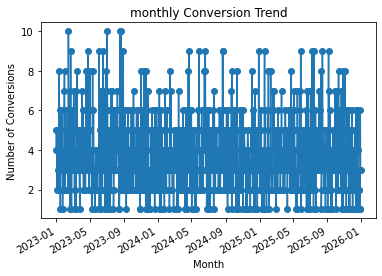

In [73]:
dfcj.groupby('VisitDate')['JourneyID'].count().plot(kind='line', marker='o')


plt.title('monthly Conversion Trend')
plt.xlabel('Month')
plt.ylabel('Number of Conversions')

plt.show()

In [74]:
merged_dfc_dfcj['Month'] = merged_dfc_dfcj['VisitDate'].dt.to_period('M')

In [75]:
monthly_conversion = merged_dfc_dfcj.groupby('Month')['JourneyID'].count()

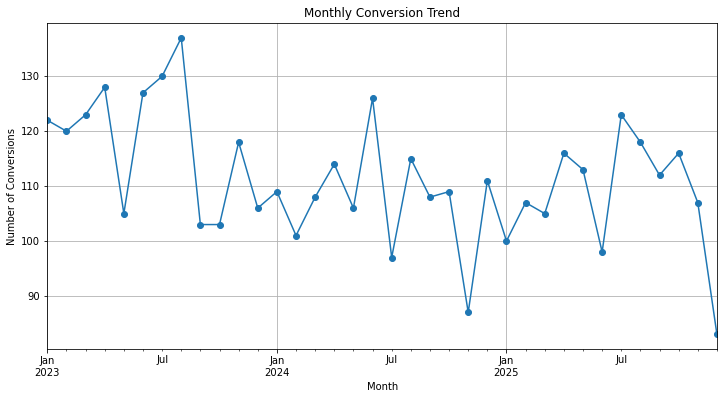

In [76]:
plt.figure(figsize=(12,6))

monthly_conversion.plot(kind='line', marker='o')

plt.title('Monthly Conversion Trend')
plt.xlabel('Month')
plt.ylabel('Number of Conversions')

plt.grid(True)
plt.show()

# Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.

In [77]:
CTR= dfce.groupby('CompaignID')[['Views','Click']].sum()

In [78]:
CTR['CTR'] = (CTR['Click']/CTR['Views'])*100

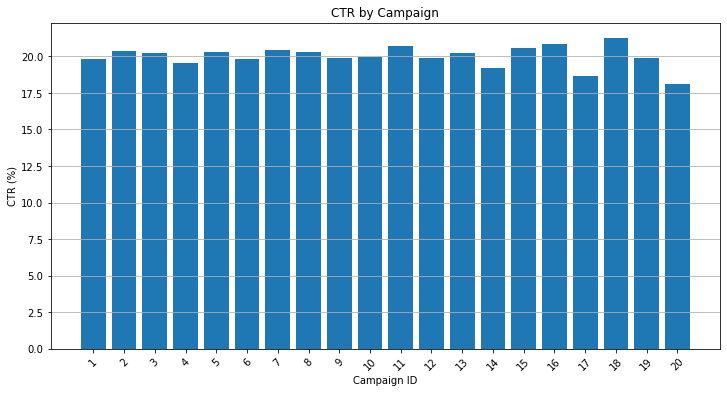

In [79]:
plt.figure(figsize=(12,6))

plt.bar(CTR.index.astype(str), CTR['CTR'])

plt.title('CTR by Campaign')
plt.xlabel('Campaign ID')
plt.ylabel('CTR (%)')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

# Top performing aur lowest performing campaigns identify karein.

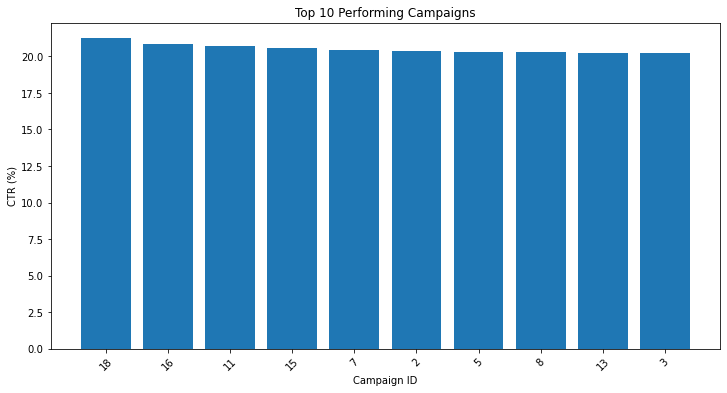

In [80]:
top10 = CTR.sort_values(by='CTR', ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top10.index.astype(str), top10['CTR'])

plt.title('Top 10 Performing Campaigns')
plt.xlabel('Campaign ID')
plt.ylabel('CTR (%)')

plt.xticks(rotation=45)

plt.show()

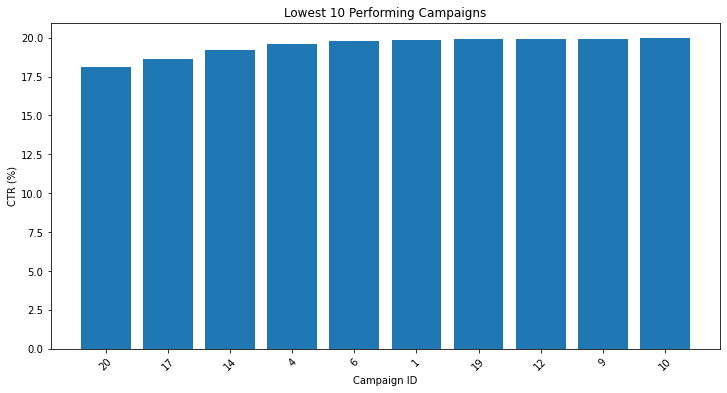

In [81]:
low10 = CTR.sort_values(by='CTR', ascending=True).head(10)

plt.figure(figsize=(12,6))

plt.bar(low10.index.astype(str), low10['CTR'])

plt.title('Lowest 10 Performing Campaigns')
plt.xlabel('Campaign ID')
plt.ylabel('CTR (%)')

plt.xticks(rotation=45)

plt.show()

# Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.


In [82]:
merged_dfcr_dfce['Engagement'] = (merged_dfcr_dfce['Click'] + merged_dfcr_dfce['Likes'])

NameError: name 'merged_dfcr_dfce' is not defined

In [86]:
merged_dfcr_dfce =pd.merge(dfcr,dfce , on='ProductID')

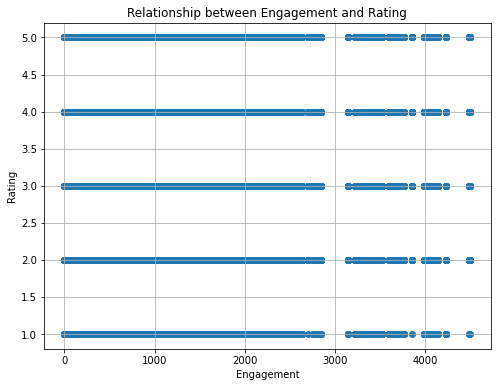

In [88]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_dfcr_dfce['Engagement'],
    merged_dfcr_dfce['Rating']
)

plt.title('Relationship between Engagement and Rating')
plt.xlabel('Engagement')
plt.ylabel('Rating')

plt.grid(True)

# Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.

In [89]:
datasets = {
    "Customers": dfc,
    "Products": dfcp,
    "Geography": dfcg,
    "Engagement": dfce,
    "Reviews": dfcr,
    "Journey": dfcj,
    "Journey Updated": dfcju
}
for name,df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Customers
['CustomerID', 'CustomerName', 'Email', 'Gender', 'Age', 'GeographyID', 'Age_Category']

Products
['ProductID', 'ProductName', 'Category', 'Price']

Geography
['ID', 'Region', 'City']

Engagement
['EngagementID', 'ContentID', 'ContentType', 'Likes', 'EngagementDate', 'CompaignID', 'ProductID', 'ViewsClickCombined', 'Views', 'Click']

Reviews
['ReviewID', 'CustomerID', 'ProductID', 'ReviewDate', 'Rating', 'ReviewText']

Journey
['JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']

Journey Updated
['Unnamed: 0', 'JourneyID', 'CustomerID', 'ProductId', 'VisitDate', 'Stage', 'Action', 'Duration']


In [90]:
dfcj = dfcj.rename(columns = {'ProductId':'ProductID'})

In [ ]:
merged_dfcr_dfce_dfcj = pd.merge(merged_dfcr_dfce,dfcj , on='ProductID' )

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = merged_dfcr_dfce_dfcj[['Views','Click','Likes','Rating','Duration']].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix Heatmap')

plt.show()